# Integrating back orbits

The final test for a HVS is proving Galactic Center object, for this purpose we will use the full 6D astrometric solution and integrate back the orbit. If the point in which the object crosses the plane is the galactic center, and we can tell that with enough certainty, then the star will be confirmed as a Hills mechanims origin HVS.

## set up

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord, Galactocentric
import sys
import astropy.units as u
import matplotlib.pyplot as plt
import os

import agama
import numpy as np
from astropy.coordinates import SkyCoord, Galactocentric
from astropy import units as u
from tqdm import tqdm
import os
import astropy.units as u


# Load data for the star we will integrate

In [36]:
# set current directory to /app/data so we can work with relative paths
os.chdir('/app/data/')
desi_hvs1 = Table.read('Data/Candidates/supersolar_gc05_candidate.fits')

# Integrate a single orbit with AGAMA for hvs3

To start we will integrate the orbito of a newly discovered HVS candidate in DESI. So we need for this star the full 6D phase space information in the form of RA, DEC, distance, pmra, pmdec and radial velocity. We can make sure that we have it for desi_hvs1 with proper motion and sky position from gaia, radial velocity from DESI and distance from Specdis

In [37]:
# print the 6D phase space information for desi_hvs1
desi_hvs1['ra', 'dec', 'pmra', 'pmdec', 'VRAD_1', 'DIST']

ra,dec,pmra,pmdec,VRAD_1,DIST
deg,deg,mas / yr,mas / yr,km / s,kpc
float64,float64,float64,float64,float64,float64
312.79049969459703,-1.008065080787321,-12.59277321466189,-13.804442503419509,-171.77378193262507,4.780515406160908


AGAMA needs to be initialized. This is important to set the units that we will be dealing with, and the potential that we will be working with, here we use the McMillan 2017 potential described in: https://arxiv.org/abs/1608.00971

In [38]:

# Define AGAMA potential and units
agama.setUnits(mass=1, length=1, velocity=1)  # kpc, km/s, M_sun
potential_file = '/app/data/AGAMA/Agama/data/McMillan17.ini' # This is a file that comes with AGAMA, and contains a Milky Way-like potential
potential = agama.Potential(potential_file)


### Now we transform the coordinates to a galactocentric cartesian system for integration

In [ ]:
from astropy.coordinates import Galactocentric

# note that we do not put units here because they are already in the right units
# in the table as the fits format can store units
c = SkyCoord(
            ra=desi_hvs1['ra'] , dec=desi_hvs1['dec'] , 
            distance=desi_hvs1['DIST'] , pm_ra_cosdec=desi_hvs1['pmra'] , 
            pm_dec=desi_hvs1['pmdec'] , radial_velocity=desi_hvs1['VRAD_2'] 
        )

galactic = c.transform_to(Galactocentric())
x, y, z = galactic.x.to_value(u.kpc), galactic.y.to_value(u.kpc), galactic.z.to_value(u.kpc)
vx, vy, vz = galactic.v_x.to_value(u.km / u.s), galactic.v_y.to_value(u.km / u.s), galactic.v_z.to_value(u.km / u.s)

# Prepare initial conditions for AGAMA
ic = np.array([x, y, z, vx, vy, vz]).ravel()  # Initial conditions

Integrating back: -0.5 gyr


In [40]:

# print(f"Initial Galactocentric coordinates:")
print(f"X: {x[0]:.2f} kpc, Y: {y[0]:.2f} kpc, Z: {z[0]:.2f} kpc")
print(f"VX: {vx[0]:.2f} km/s, VY: {vy[0]:.2f} km/s, VZ: {vz[0]:.2f} km/s")


X: -5.20 kpc, Y: 3.10 kpc, Z: -2.15 kpc
VX: 236.99 km/s, VY: -120.39 km/s, VZ: 164.78 km/s


## Here the actual integration happens

Note that we set the time to be negative, so we are seeing where the star comes from (the goal), instead of looking at where it is going

In [41]:
integration_time =-0.5 # in Gyr
print('Integrating back:', integration_time, 'gyr')


Integrating back: -0.5 gyr


In [42]:
# Integrate orbit
orbit = agama.orbit(potential=potential, ic=ic, time=integration_time, dtype= object)
trajectory = orbit(orbit)[:, :3]
z_vals = trajectory[:, 2]
times = [t for t in orbit] # Time values
velocities = orbit(orbit)[:, 3:6]

Doing it this way, without passing specific time steps allows for agama to internally decide how many time steps and adapt depending on the potential. It returns an interpolator that if we pass itself we get the adaptive time steps. We can also use this interpolator to get the position of the star at any time.

## Plot the orbit

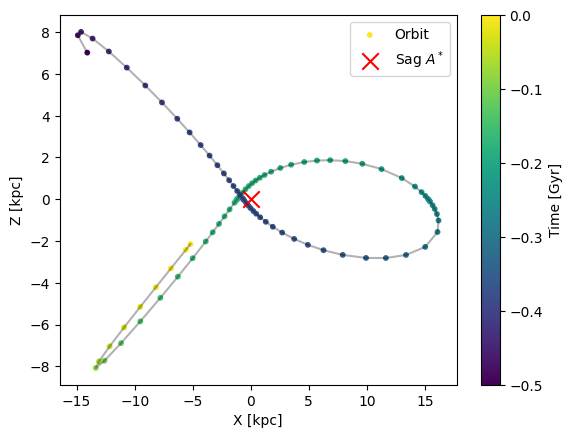

In [33]:
fig, ax = plt.subplots()
cbar = ax.scatter(trajectory[:,0], trajectory[:,2], c = times, label='Orbit', s = 10)
ax.plot(trajectory[:,0], trajectory[:,2], color='black', alpha=0.3)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Z [kpc]')
plt.colorbar(cbar, label='Time [Gyr]')
ax.scatter(0, 0, c='r', label = 'Sag $A^*$', s = 140, marker='x')
plt.legend()
plt.show()

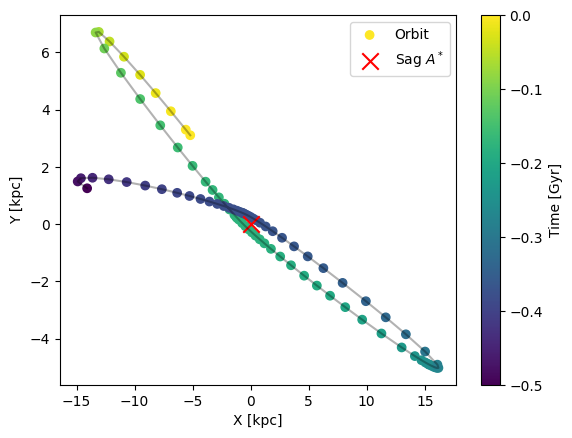

In [34]:
fig, ax = plt.subplots()
cbar = ax.scatter(trajectory[:,0], trajectory[:,1], c = times, label='Orbit')
ax.plot(trajectory[:,0], trajectory[:,1], color='black', alpha=0.3)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
plt.colorbar(cbar, label='Time [Gyr]')
ax.scatter(0, 0, c='r', label = 'Sag $A^*$', s = 140, marker='x', alpha = 1)
plt.legend()
#bound = 20
#ax.set_xlim(-bound, bound)
#ax.set_ylim(-bound, bound)
plt.show()

## Integrate for longer, how about 5 Gyr to see a few orbits


In [43]:
# Integrate orbit
orbit = agama.orbit(potential=potential, ic=ic, time=-5, dtype= object)
trajectory = orbit(orbit)[:, :3]
z_vals = trajectory[:, 2]
times = [t for t in orbit] # Time values
velocities = orbit(orbit)[:, 3:6]

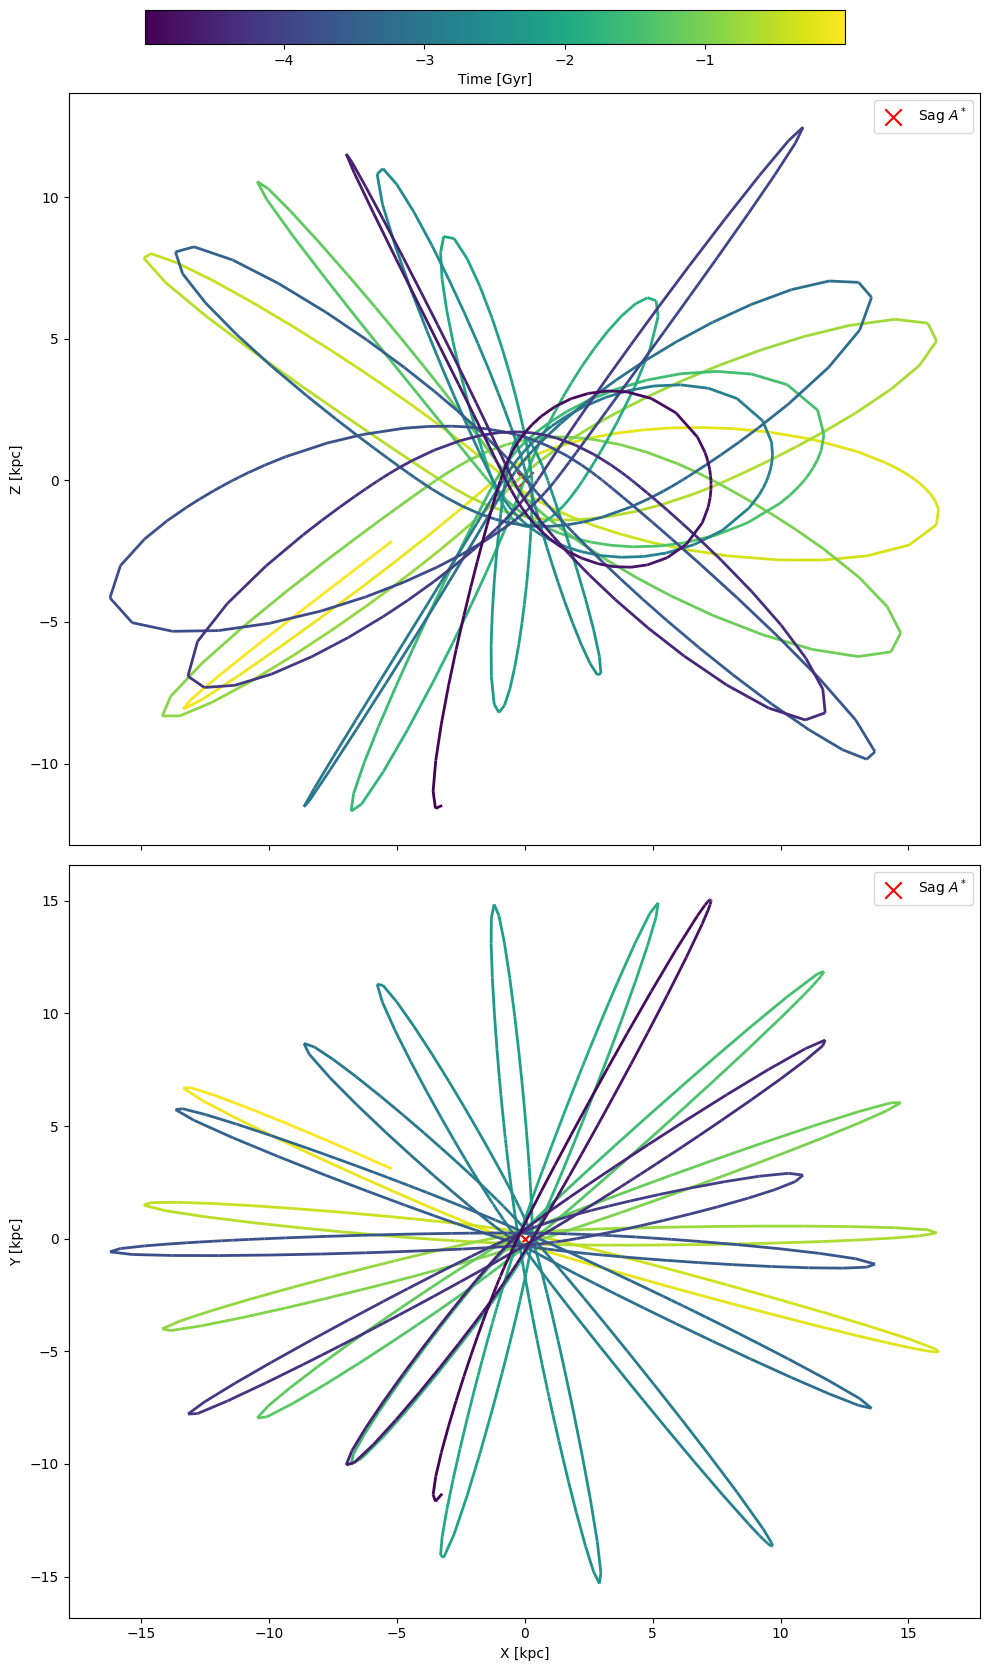

In [53]:

from matplotlib.collections import LineCollection

# --- helper to make a coloured-line Axes ---------------------------------------------------------
def coloured_line(ax, x, y, t, cmap='viridis', lw=2, **kw):
    """
    Add a line to *ax* that is coloured by the values in *t*.

    Parameters
    ----------
    ax   : matplotlib Axes
    x,y  : 1-D arrays of the same length
    t    : 1-D array of the same length (times used for colouring)
    cmap : str or Colormap
    lw   : line-width
    kw   : any other LineCollection keyword args (alpha, zorder, etc.)

    Returns
    -------
    lc   : the LineCollection, which behaves like a normal artist
    """
    # build Nx1x2 array of points, then N-1x2x2 array of segments
    points    = np.column_stack((x, y)).reshape(-1, 1, 2)
    segments  = np.concatenate([points[:-1], points[1:]], axis=1)

    # colour per segment; use the average time for smoother mapping
    t_seg = 0.5 * (t[:-1] + t[1:])

    lc = LineCollection(segments, cmap=cmap, linewidths=lw, **kw)
    lc.set_array(t_seg)
    ax.add_collection(lc)
    return lc
# -----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 1, figsize=(10, 17), sharex=True)

# Top panel: X–Z
lc0 = coloured_line(
    ax[0],
    trajectory[:, 0],
    trajectory[:, 2],
    np.array(times),
    cmap='viridis',
    lw=2,
    alpha=1.0,
)
ax[0].scatter(0, 0, c='r', label='Sag $A^*$', s=140, marker='x')
ax[0].set_ylabel('Z [kpc]')
ax[0].legend()

# Bottom panel: X–Y
lc1 = coloured_line(
    ax[1],
    trajectory[:, 0],
    trajectory[:, 1],
    np.array(times),
    cmap='viridis',
    lw=2,
    alpha=1.0,
)
ax[1].scatter(0, 0, c='r', label='Sag $A^*$', s=140, marker='x')
ax[1].set_xlabel('X [kpc]')
ax[1].set_ylabel('Y [kpc]')
ax[1].legend()

# -- reserve space at top for the colour-bar --
fig.tight_layout(rect=[0, 0, 1, 0.94])   # left, bottom, right, top

# -- colour-bar uses any one of the LineCollections --
cbar_ax = fig.add_axes([0.15, 0.96, 0.7, 0.02])
fig.colorbar(
    lc0,                     # any mappable – both share the same colormap/norm
    cax=cbar_ax,
    orientation='horizontal',
    label='Time [Gyr]',
)

plt.show()
